In [1]:
# Import libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("ai4i2020.csv")

# Display first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ai4i2020.csv'

In [2]:
from google.colab import files

uploaded = files.upload()

Saving ai4i+2020+predictive+maintenance+dataset.zip to ai4i+2020+predictive+maintenance+dataset (1).zip


In [3]:
import zipfile
import os

zip_file = next(iter(uploaded))

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Files extracted:")
print(os.listdir("dataset"))

Files extracted:
['ai4i2020.csv']


In [4]:
import os

for root, dirs, files in os.walk("dataset"):
    for file in files:
        print(os.path.join(root, file))

dataset/ai4i2020.csv


In [5]:
import pandas as pd

df = pd.read_csv("dataset/ai4i2020.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [6]:
# Check the target variable

print("Machine Failure Distribution:")
print(df["Machine failure"].value_counts())

print("\nMachine Failure Percentage:")
print(df["Machine failure"].value_counts(normalize=True) * 100)

Machine Failure Distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Machine Failure Percentage:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


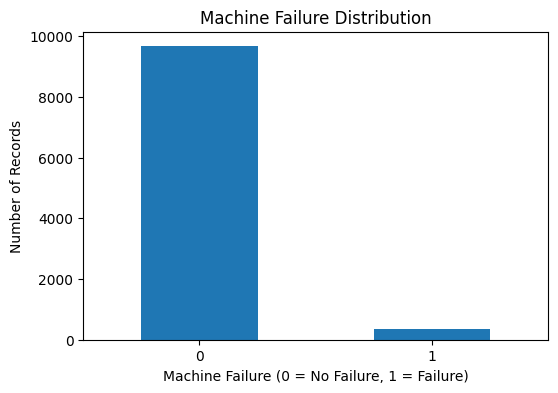

In [7]:
# Visualize machine failure distribution

import matplotlib.pyplot as plt

df["Machine failure"].value_counts().plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure (0 = No Failure, 1 = Failure)")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.show()

In [8]:
# Display dataset information

print("Column Information:\n")

for column in df.columns:
    print(f"{column}")
    print(f"  Data type: {df[column].dtype}")
    print(f"  Unique values: {df[column].nunique()}")
    print(f"  Example: {df[column].iloc[0]}")
    print("-" * 60)

Column Information:

UDI
  Data type: int64
  Unique values: 10000
  Example: 1
------------------------------------------------------------
Product ID
  Data type: object
  Unique values: 10000
  Example: M14860
------------------------------------------------------------
Type
  Data type: object
  Unique values: 3
  Example: M
------------------------------------------------------------
Air temperature [K]
  Data type: float64
  Unique values: 93
  Example: 298.1
------------------------------------------------------------
Process temperature [K]
  Data type: float64
  Unique values: 82
  Example: 308.6
------------------------------------------------------------
Rotational speed [rpm]
  Data type: int64
  Unique values: 941
  Example: 1551
------------------------------------------------------------
Torque [Nm]
  Data type: float64
  Unique values: 577
  Example: 42.8
------------------------------------------------------------
Tool wear [min]
  Data type: int64
  Unique values: 246

In [9]:
# Statistical summary of numerical columns

df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [10]:
# Display all column names clearly

print(df.columns.tolist())

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [11]:
# Make a copy of the original dataset
data = df.copy()

# Remove identifier columns
data = data.drop(columns=["UDI", "Product ID"])

# Remove failure-mode columns to avoid data leakage
failure_mode_columns = ["TWF", "HDF", "PWF", "OSF", "RNF"]

data = data.drop(columns=failure_mode_columns)

# Display remaining columns
print("Columns after removing IDs and leakage-prone failure indicators:")
print(data.columns.tolist())

print("\nDataset shape:")
print(data.shape)

Columns after removing IDs and leakage-prone failure indicators:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']

Dataset shape:
(10000, 7)


In [13]:
# Check duplicate rows

print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 0


In [14]:
# Check missing values

print("Missing values:")
print(data.isnull().sum())

Missing values:
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
dtype: int64


In [15]:
# Check product types

print(data["Type"].value_counts())

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


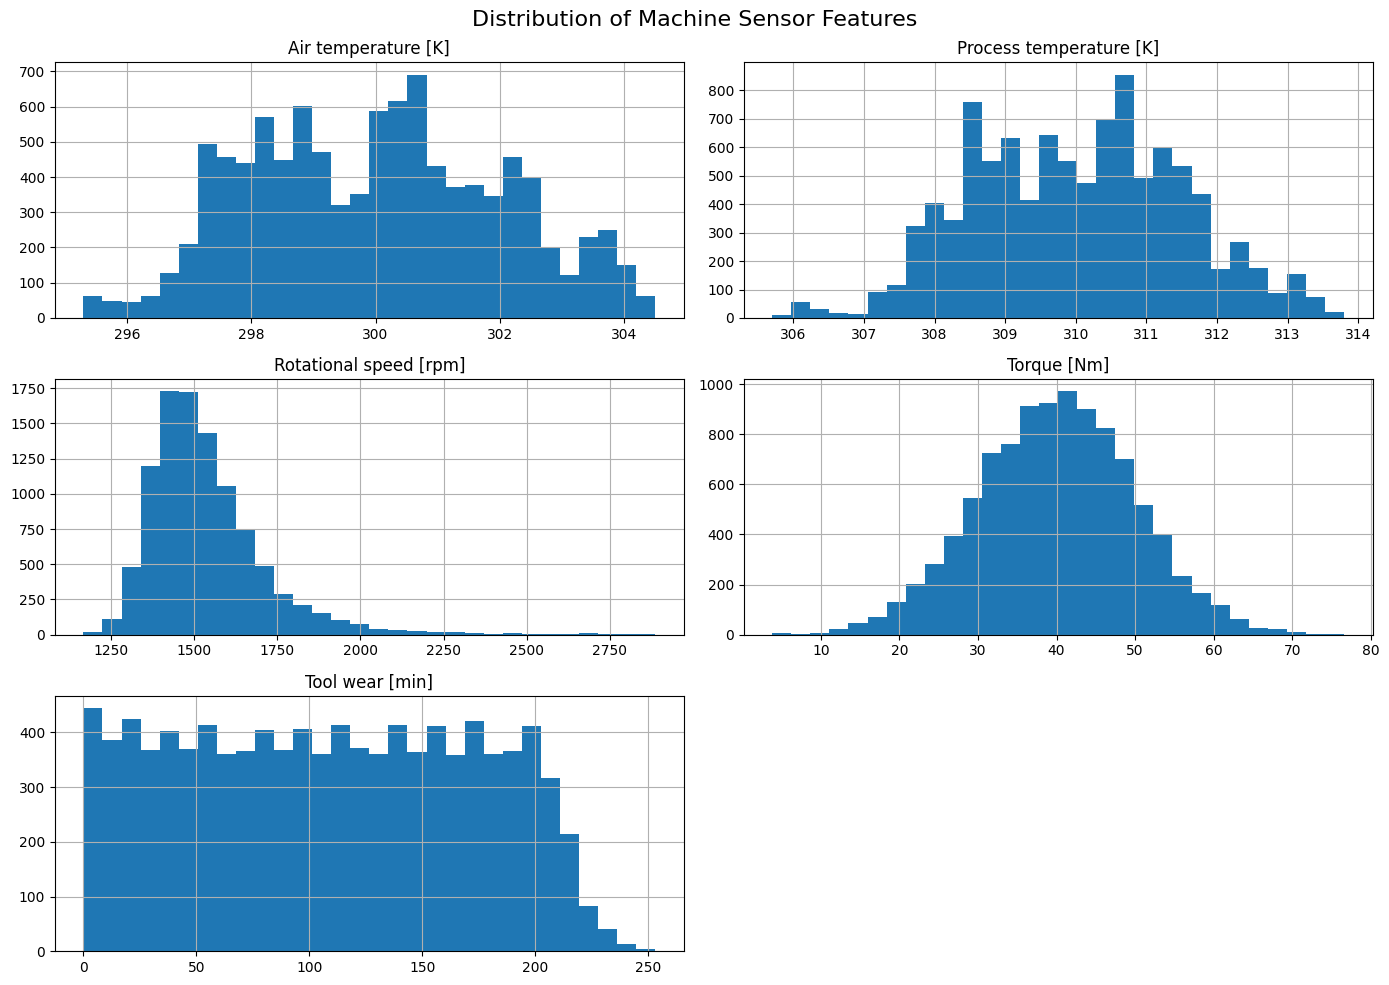

In [16]:
import matplotlib.pyplot as plt

# Select numerical features
numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

# Plot distributions
data[numerical_features].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribution of Machine Sensor Features", fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
failure_by_type = (
    data.groupby("Type")["Machine failure"]
    .mean()
    .sort_values(ascending=False)
)

print(failure_by_type)

Type
L    0.039167
M    0.027694
H    0.020937
Name: Machine failure, dtype: float64


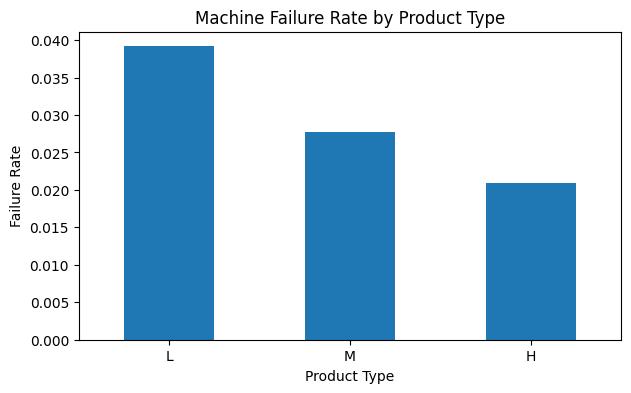

In [18]:
failure_by_type.plot(
    kind="bar",
    figsize=(7, 4)
)

plt.title("Machine Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate")
plt.xticks(rotation=0)
plt.show()

In [19]:
data.groupby("Machine failure")[numerical_features].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


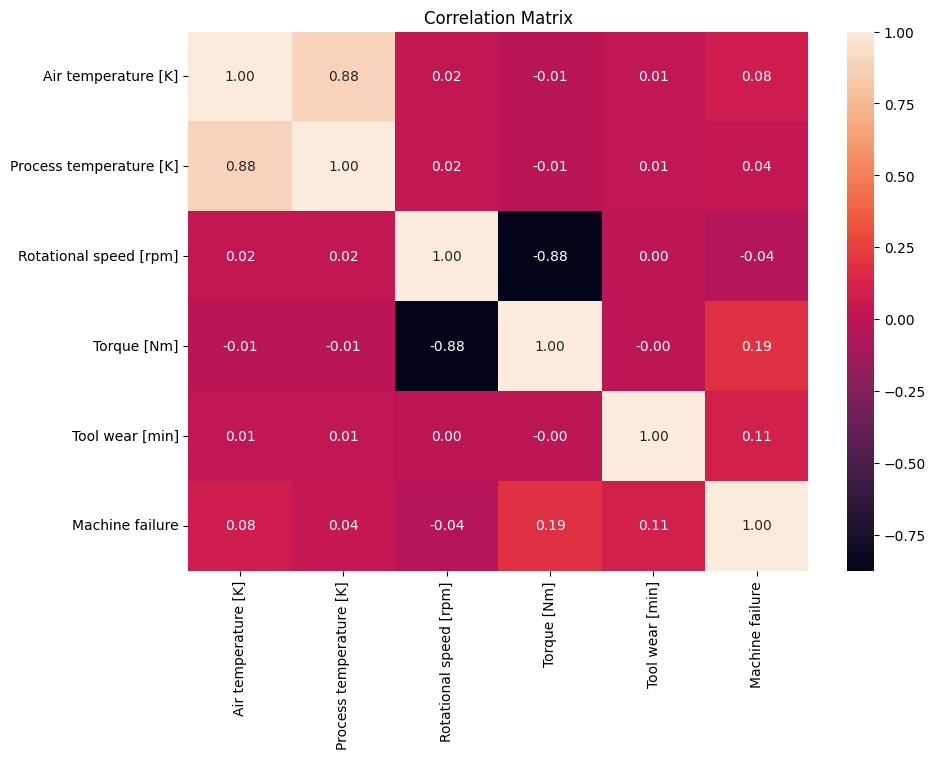

In [20]:
import seaborn as sns

correlation = data[numerical_features + ["Machine failure"]].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

<Figure size 700x500 with 0 Axes>

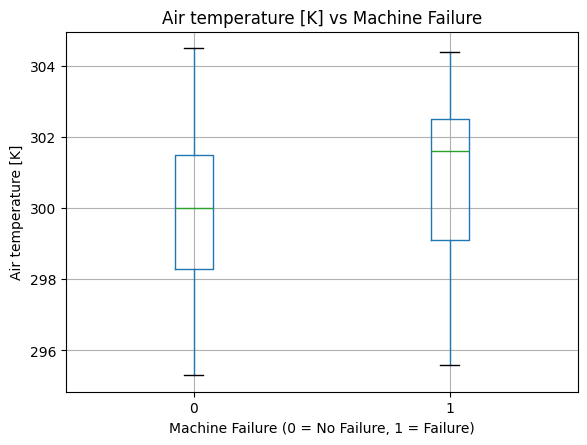

<Figure size 700x500 with 0 Axes>

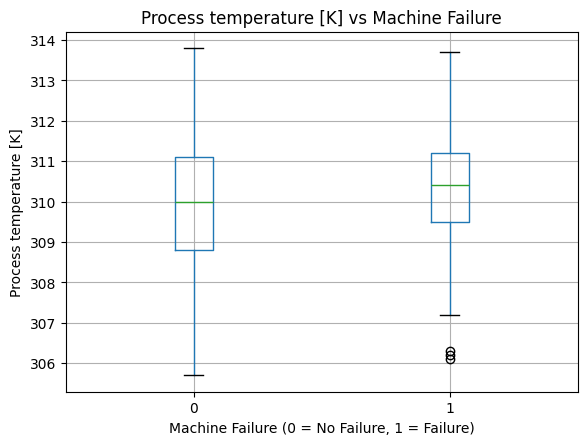

<Figure size 700x500 with 0 Axes>

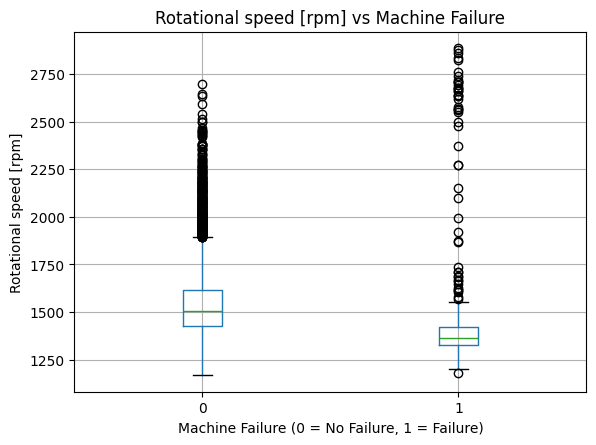

<Figure size 700x500 with 0 Axes>

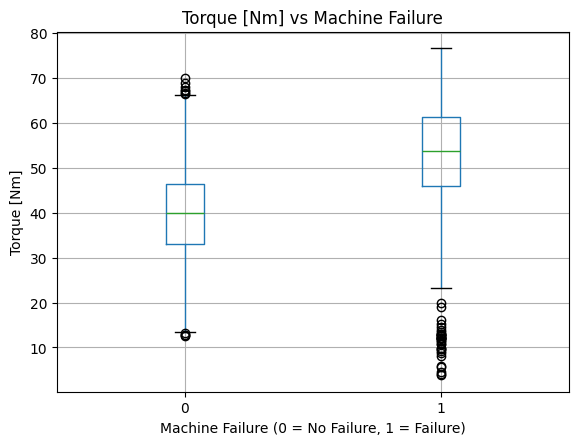

<Figure size 700x500 with 0 Axes>

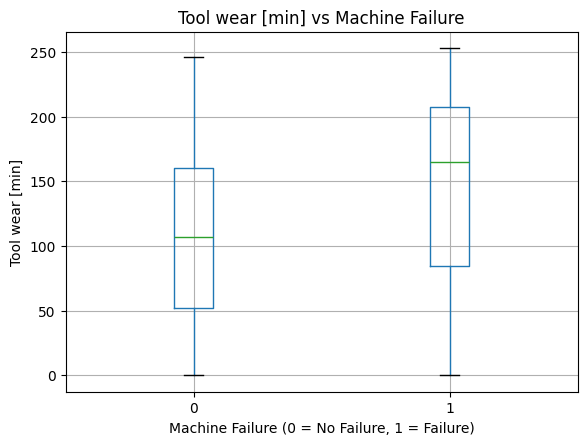

In [21]:
import matplotlib.pyplot as plt

features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

for feature in features:
    plt.figure(figsize=(7, 5))

    data.boxplot(
        column=feature,
        by="Machine failure"
    )

    plt.title(f"{feature} vs Machine Failure")
    plt.suptitle("")
    plt.xlabel("Machine Failure (0 = No Failure, 1 = Failure)")
    plt.ylabel(feature)

    plt.show()

In [22]:
failure_comparison = data.groupby("Machine failure")[features].mean().T

failure_comparison.columns = [
    "No Failure",
    "Failure"
]

failure_comparison

,No Failure,Failure
Air temperature [K],299.973999,300.886431
Process temperature [K],309.995570,310.290265
Rotational speed [rpm],1540.260014,1496.486726
Torque [Nm],39.629655,50.168142
Tool wear [min],106.693717,143.781711


In [23]:
comparison = data.groupby("Machine failure")[features].mean().T

comparison["Difference"] = (
    comparison[1] - comparison[0]
)

comparison["Percentage Difference"] = (
    (comparison[1] - comparison[0])
    / comparison[0]
) * 100

comparison

Machine failure,0,1,Difference,Percentage Difference
Air temperature [K],299.973999,300.886431,0.912432,0.304170
Process temperature [K],309.995570,310.290265,0.294696,0.095064
Rotational speed [rpm],1540.260014,1496.486726,-43.773289,-2.841942
Torque [Nm],39.629655,50.168142,10.538486,26.592425
Tool wear [min],106.693717,143.781711,37.087994,34.761179


In [24]:
# Create temperature difference

data["Temperature Difference [K]"] = (
    data["Process temperature [K]"]
    - data["Air temperature [K]"]
)

data[[
    "Air temperature [K]",
    "Process temperature [K]",
    "Temperature Difference [K]"
]].head()

,Air temperature [K],Process temperature [K],Temperature Difference [K]
0,298.1,308.6,10.5
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,298.2,308.6,10.4
4,298.2,308.7,10.5


In [25]:
import numpy as np

# Convert rotational speed from RPM to radians/second
angular_velocity = (
    2 * np.pi * data["Rotational speed [rpm]"] / 60
)

# Calculate approximate mechanical power in Watts
data["Mechanical Power [W]"] = (
    data["Torque [Nm]"] * angular_velocity
)

data[[
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Mechanical Power [W]"
]].head()

,Rotational speed [rpm],Torque [Nm],Mechanical Power [W]
0,1551,42.8,6951.590560
1,1408,46.3,6826.722724
2,1498,49.4,7749.387543
3,1433,39.5,5927.504659
4,1408,40.0,5897.816608


In [26]:
def classify_tool_wear(wear):
    if wear < 50:
        return "Low"
    elif wear < 150:
        return "Medium"
    else:
        return "High"

data["Tool Wear Level"] = data["Tool wear [min]"].apply(
    classify_tool_wear
)

data["Tool Wear Level"].value_counts()

,count
Tool Wear Level,
Medium,4561
High,3090
Low,2349


In [27]:
print("Updated dataset shape:", data.shape)

print("\nNew columns:")
print(data.columns.tolist())

display(data.head())

Updated dataset shape: (10000, 10)

New columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Temperature Difference [K]', 'Mechanical Power [W]', 'Tool Wear Level']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Temperature Difference [K],Mechanical Power [W],Tool Wear Level
0,M,298.1,308.6,1551,42.8,0,0,10.5,6951.590560,Low
1,L,298.2,308.7,1408,46.3,3,0,10.5,6826.722724,Low
2,L,298.1,308.5,1498,49.4,5,0,10.4,7749.387543,Low
3,L,298.2,308.6,1433,39.5,7,0,10.4,5927.504659,Low
4,L,298.2,308.7,1408,40.0,9,0,10.5,5897.816608,Low


In [28]:
# Separate features and target

X = data.drop(columns=["Machine failure"])
y = data["Machine failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 9)
y shape: (10000,)


In [29]:
# One-hot encode the Type column

X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=True
)

print("Features after encoding:")
print(X.columns.tolist())

Features after encoding:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature Difference [K]', 'Mechanical Power [W]', 'Tool Wear Level', 'Type_L', 'Type_M']


In [30]:
# Check target distribution

print(y.value_counts())
print("\nTarget percentages:")
print(y.value_counts(normalize=True) * 100)

Machine failure
0    9661
1     339
Name: count, dtype: int64

Target percentages:
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (8000, 10)
Testing data: (2000, 10)

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [32]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nMissing values in X_train:")
print(X_train.isnull().sum().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum().sum())

X_train: (8000, 10)
X_test : (2000, 10)
y_train: (8000,)
y_test : (2000,)

Missing values in X_train:
0

Missing values in X_test:
0


In [34]:
# Separate features and target

X = data.drop(columns=["Machine failure"])
y = data["Machine failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 9)
y shape: (10000,)


In [35]:
# Check data types

print(X.dtypes)

Type                           object
Air temperature [K]           float64
Process temperature [K]       float64
Rotational speed [rpm]          int64
Torque [Nm]                   float64
Tool wear [min]                 int64
Temperature Difference [K]    float64
Mechanical Power [W]          float64
Tool Wear Level                object
dtype: object


In [36]:
# One-hot encode categorical features

X = pd.get_dummies(
    X,
    columns=["Type", "Tool Wear Level"],
    drop_first=True,
    dtype=int
)

print("Features after encoding:")
print(X.columns.tolist())

print("\nNew X shape:", X.shape)

Features after encoding:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature Difference [K]', 'Mechanical Power [W]', 'Type_L', 'Type_M', 'Tool Wear Level_Low', 'Tool Wear Level_Medium']

New X shape: (10000, 11)


In [37]:
# Verify data types

print(X.dtypes)

print("\nNon-numeric columns:")
print(X.select_dtypes(exclude=["number"]).columns.tolist())

Air temperature [K]           float64
Process temperature [K]       float64
Rotational speed [rpm]          int64
Torque [Nm]                   float64
Tool wear [min]                 int64
Temperature Difference [K]    float64
Mechanical Power [W]          float64
Type_L                          int64
Type_M                          int64
Tool Wear Level_Low             int64
Tool Wear Level_Medium          int64
dtype: object

Non-numeric columns:
[]


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 11)
X_test : (2000, 11)
y_train: (8000,)
y_test : (2000,)


In [39]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [40]:
# Generate predictions on the test set

y_pred_baseline = baseline_model.predict(X_test)

# Generate probability of machine failure (class 1)
y_prob_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 10 predicted classes:")
print(y_pred_baseline[:10])

print("\nFirst 10 failure probabilities:")
print(y_prob_baseline[:10])

Predictions generated successfully!

First 10 predicted classes:
[1 0 0 0 0 0 0 0 0 0]

First 10 failure probabilities:
[5.58567447e-01 1.33994489e-02 4.06718437e-02 1.88489507e-04
 1.00745443e-01 4.24218795e-02 6.06302244e-02 7.41508880e-03
 2.58954546e-04 1.73978889e-01]


In [41]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred_baseline)
precision = precision_score(y_test, y_pred_baseline, zero_division=0)
recall = recall_score(y_test, y_pred_baseline, zero_division=0)
f1 = f1_score(y_test, y_pred_baseline, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob_baseline)

# Display results
print("Baseline Logistic Regression Results")
print("=" * 45)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Baseline Logistic Regression Results
Accuracy : 0.9695
Precision: 0.6400
Recall   : 0.2353
F1 Score : 0.3441
ROC-AUC  : 0.9280


In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_baseline)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

Confusion Matrix:
[[1923    9]
 [  52   16]]

True Negatives : 1923
False Positives: 9
False Negatives: 52
True Positives  : 16


In [44]:
# Install XGBoost
!pip install -q xgboost

In [45]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.4.1


In [46]:
# Calculate class imbalance ratio

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Non-failure cases:", negative_count)
print("Failure cases:", positive_count)
print("Scale Pos Weight:", scale_pos_weight)

Non-failure cases: 7729
Failure cases: 271
Scale Pos Weight: 28.52029520295203


In [47]:
# Create XGBoost classifier

xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=42,
    n_jobs=-1
)

print("XGBoost model created successfully!")

XGBoost model created successfully!


In [48]:
# Train XGBoost

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("XGBoost model trained successfully!")

ValueError: feature_names must be string, and may not contain [, ] or <

In [49]:
# Create clean feature names for XGBoost

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

# Replace special characters with safe characters
X_train_xgb.columns = (
    X_train_xgb.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
    .str.replace(" ", "_", regex=False)
)

X_test_xgb.columns = X_train_xgb.columns

print("XGBoost feature names:")
print(X_train_xgb.columns.tolist())

XGBoost feature names:
['Air_temperature__K_', 'Process_temperature__K_', 'Rotational_speed__rpm_', 'Torque__Nm_', 'Tool_wear__min_', 'Temperature_Difference__K_', 'Mechanical_Power__W_', 'Type_L', 'Type_M', 'Tool_Wear_Level_Low', 'Tool_Wear_Level_Medium']


In [51]:
# Train XGBoost again using the cleaned feature names

xgb_model.fit(
    X_train_xgb,
    y_train,
    eval_set=[(X_test_xgb, y_test)],
    verbose=False
)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [53]:
# Step 7E - Generate XGBoost predictions

y_pred_xgb = xgb_model.predict(X_test_xgb)

y_prob_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

print("XGBoost predictions generated successfully!")
print("Predictions:", y_pred_xgb[:10])
print("Probabilities:", y_prob_xgb[:10])

XGBoost predictions generated successfully!
Predictions: [0 0 0 0 0 0 0 0 0 0]
Probabilities: [3.8116419e-01 8.9547649e-04 4.0614909e-01 2.1001587e-03 1.0898634e-01
 2.6490451e-03 8.0288731e-02 1.3793770e-03 2.7794376e-04 3.8631991e-02]


In [54]:
# Step 7F - Evaluate XGBoost

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_test, y_pred_xgb, zero_division=0)
xgb_f1 = f1_score(y_test, y_pred_xgb, zero_division=0)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("=" * 45)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost Results
Accuracy : 0.9810
Precision: 0.6667
Recall   : 0.8824
F1 Score : 0.7595
ROC-AUC  : 0.9768


In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb, zero_division=0)
xgb_recall = recall_score(y_test, y_pred_xgb, zero_division=0)
xgb_f1 = f1_score(y_test, y_pred_xgb, zero_division=0)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("=" * 45)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost Results
Accuracy : 0.9810
Precision: 0.6667
Recall   : 0.8824
F1 Score : 0.7595
ROC-AUC  : 0.9768


In [56]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        xgb_roc_auc
    ]
})

display(model_comparison)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9695,0.640000,0.235294,0.344086,0.928023
1,XGBoost,0.9810,0.666667,0.882353,0.759494,0.976754


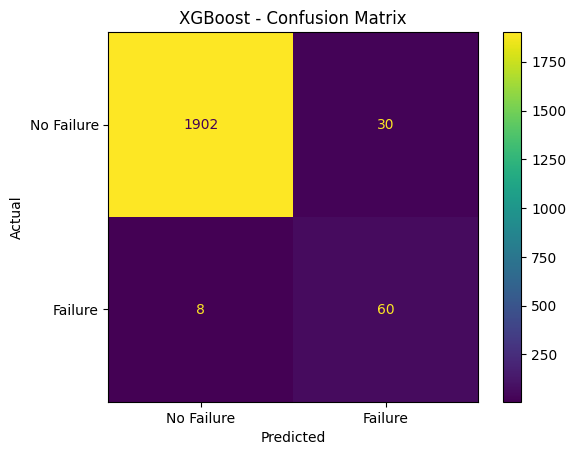

In [57]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=["No Failure", "Failure"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [58]:
# Get XGBoost feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train_xgb.columns,
    "Importance": xgb_model.feature_importances_
})

# Sort from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
2,Rotational_speed__rpm_,0.214871
4,Tool_wear__min_,0.169102
6,Mechanical_Power__W_,0.161051
3,Torque__Nm_,0.148047
5,Temperature_Difference__K_,0.072888
10,Tool_Wear_Level_Medium,0.071796
0,Air_temperature__K_,0.045861
9,Tool_Wear_Level_Low,0.034497
1,Process_temperature__K_,0.034460
8,Type_M,0.024364


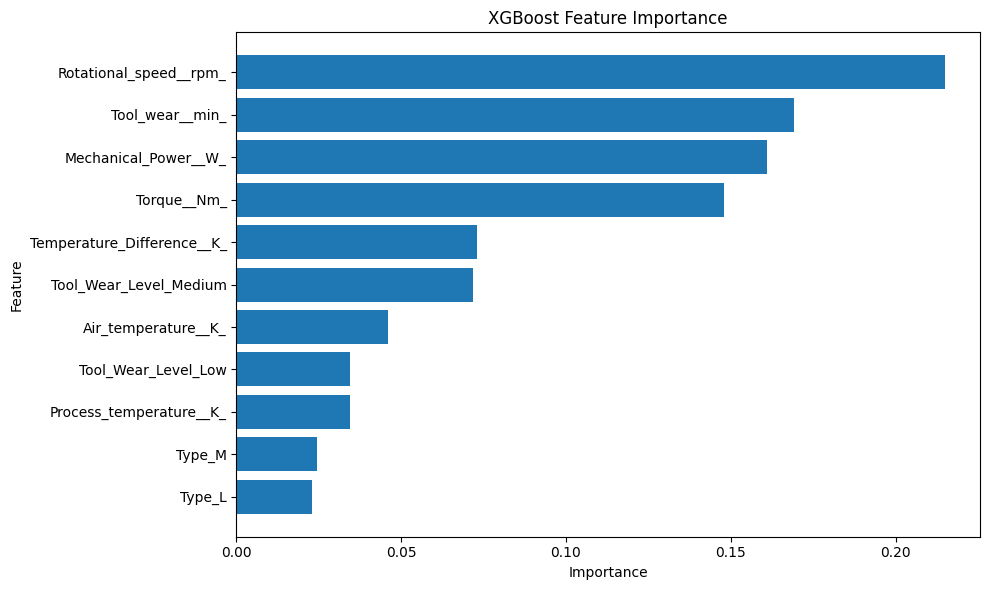

In [59]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [60]:
!pip install -q shap

In [61]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [62]:
# Create SHAP TreeExplainer

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_xgb)

print("SHAP values calculated successfully!")
print("SHAP shape:", shap_values.shape)

SHAP values calculated successfully!
SHAP shape: (2000, 11)


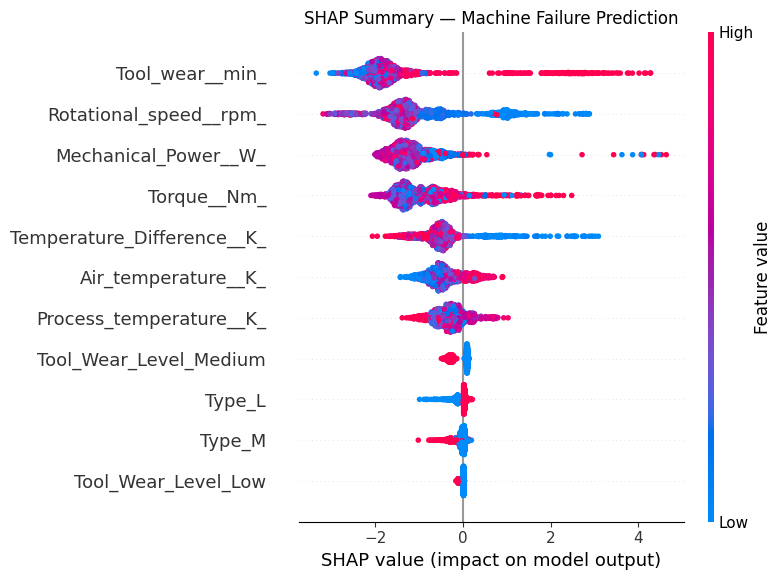

In [63]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_xgb,
    show=False
)

plt.title("SHAP Summary — Machine Failure Prediction")
plt.tight_layout()
plt.show()

Average Precision (AP): 0.8815


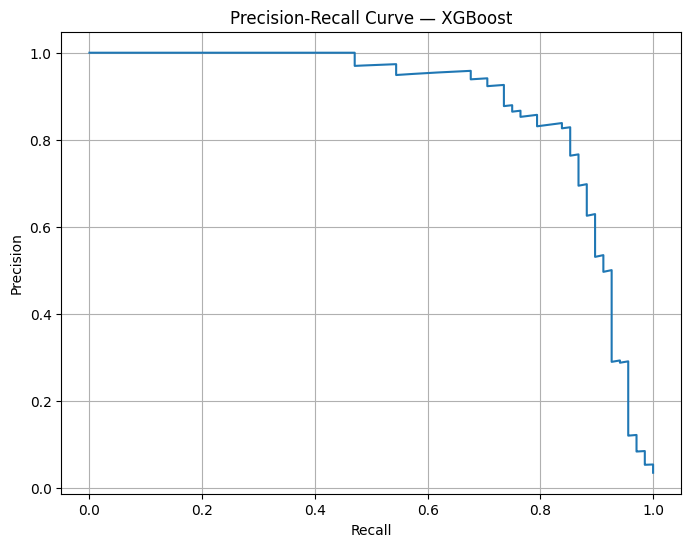

In [64]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Calculate precision, recall and thresholds
precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_test,
    y_prob_xgb
)

# Average Precision
ap_score = average_precision_score(y_test, y_prob_xgb)

print(f"Average Precision (AP): {ap_score:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost")
plt.grid(True)
plt.show()

In [65]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate F1 score at every available threshold
f1_scores = 2 * (precision_vals * recall_vals) / (
    precision_vals + recall_vals + 1e-10
)

# Ignore the final point because it has no corresponding threshold
best_index = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_index]

best_precision = precision_vals[best_index]
best_recall = recall_vals[best_index]
best_f1 = f1_scores[best_index]

print("Best Threshold:", round(best_threshold, 4))
print("Precision:", round(best_precision, 4))
print("Recall:", round(best_recall, 4))
print("F1 Score:", round(best_f1, 4))

Best Threshold: 0.7423
Precision: 0.8286
Recall: 0.8529
F1 Score: 0.8406


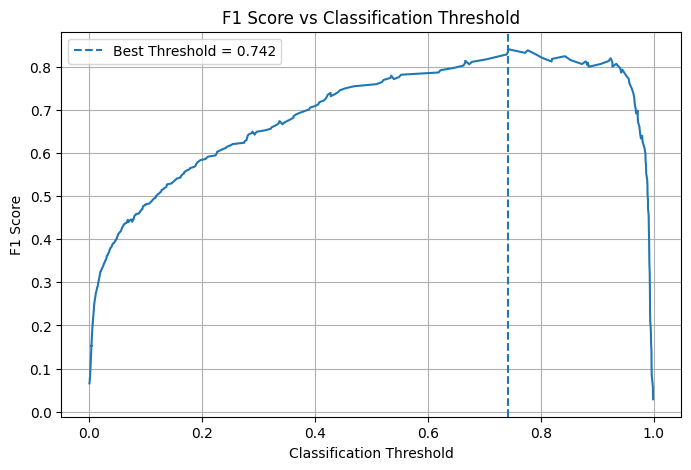

In [66]:
plt.figure(figsize=(8, 5))

plt.plot(thresholds, f1_scores[:-1])

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.3f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [67]:
y_pred_optimized = (
    y_prob_xgb >= best_threshold
).astype(int)

optimized_precision = precision_score(
    y_test,
    y_pred_optimized,
    zero_division=0
)

optimized_recall = recall_score(
    y_test,
    y_pred_optimized,
    zero_division=0
)

optimized_f1 = f1_score(
    y_test,
    y_pred_optimized,
    zero_division=0
)

print("Optimized Threshold Results")
print("-" * 35)
print(f"Threshold : {best_threshold:.4f}")
print(f"Precision : {optimized_precision:.4f}")
print(f"Recall    : {optimized_recall:.4f}")
print(f"F1 Score  : {optimized_f1:.4f}")

Optimized Threshold Results
-----------------------------------
Threshold : 0.7423
Precision : 0.8286
Recall    : 0.8529
F1 Score  : 0.8406


In [68]:
# Create final predictions using optimized XGBoost threshold

y_pred_xgb_optimized = (
    y_prob_xgb >= best_threshold
).astype(int)

# Calculate final metrics
final_xgb_accuracy = accuracy_score(
    y_test,
    y_pred_xgb_optimized
)

final_xgb_precision = precision_score(
    y_test,
    y_pred_xgb_optimized,
    zero_division=0
)

final_xgb_recall = recall_score(
    y_test,
    y_pred_xgb_optimized,
    zero_division=0
)

final_xgb_f1 = f1_score(
    y_test,
    y_pred_xgb_optimized,
    zero_division=0
)

final_xgb_roc_auc = roc_auc_score(
    y_test,
    y_prob_xgb
)

# Final comparison
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "XGBoost (Default 0.50)",
        "XGBoost (Optimized 0.7423)"
    ],
    "Accuracy": [
        accuracy,
        xgb_accuracy,
        final_xgb_accuracy
    ],
    "Precision": [
        precision,
        xgb_precision,
        final_xgb_precision
    ],
    "Recall": [
        recall,
        xgb_recall,
        final_xgb_recall
    ],
    "F1 Score": [
        f1,
        xgb_f1,
        final_xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        xgb_roc_auc,
        final_xgb_roc_auc
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9695,0.640000,0.235294,0.344086,0.928023
1,XGBoost (Default 0.50),0.9810,0.666667,0.882353,0.759494,0.976754
2,XGBoost (Optimized 0.7423),0.9890,0.828571,0.852941,0.840580,0.976754


<Figure size 700x600 with 0 Axes>

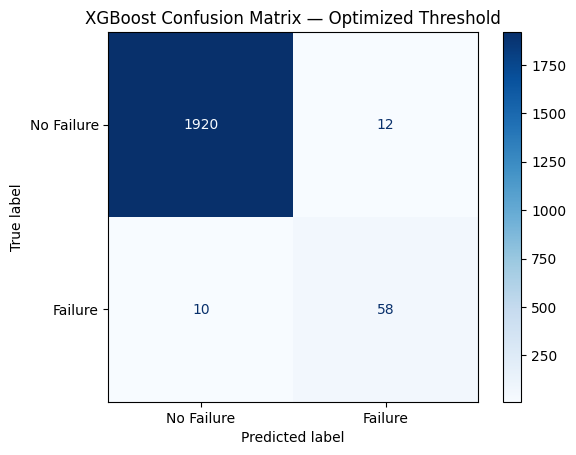

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_optimized,
    display_labels=["No Failure", "Failure"],
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix — Optimized Threshold")
plt.show()

In [70]:
from sklearn.metrics import classification_report, confusion_matrix

# Final predictions using optimized threshold
y_pred_final = (
    y_prob_xgb >= best_threshold
).astype(int)

# Classification report
print("FINAL XGBOOST CLASSIFICATION REPORT")
print("=" * 50)

print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["No Failure", "Failure"],
        digits=4,
        zero_division=0
    )
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

tn, fp, fn, tp = cm.ravel()

print("\nCONFUSION MATRIX")
print("=" * 50)
print(cm)

print("\nDETAILED RESULTS")
print("=" * 50)
print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives   (TP): {tp}")

FINAL XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  No Failure     0.9948    0.9938    0.9943      1932
     Failure     0.8286    0.8529    0.8406        68

    accuracy                         0.9890      2000
   macro avg     0.9117    0.9234    0.9174      2000
weighted avg     0.9892    0.9890    0.9891      2000


CONFUSION MATRIX
[[1920   12]
 [  10   58]]

DETAILED RESULTS
True Negatives  (TN): 1920
False Positives (FP): 12
False Negatives (FN): 10
True Positives   (TP): 58
